In [1]:
## Load modules

# Standard modules
import pandas as pd
import numpy as np

# Preprocessing modules
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler,\
 OneHotEncoder, LabelEncoder, OrdinalEncoder

# Train-test split module
from sklearn.model_selection import train_test_split

# Classifier modules
from sklearn.ensemble import RandomForestClassifier

# Regression modules
from sklearn.ensemble import RandomForestRegressor

# Model selection modules
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, GridSearchCV

# Pipeline module
from sklearn.pipeline import Pipeline

# Imputation modules
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector

# Performance metric modules
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Plotting modules
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('dark_background')
%matplotlib inline
plt.rcParams['figure.figsize'] = (4.0, 4.0) # set default size of plots

pd.options.display.max_columns = None

# Module for categorical variables
from pandas.api.types import CategoricalDtype

# Modules for building custom encoders and transformers
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
import numpy as np
import sys
import random
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline

import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Lambda
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam

2.14.0


In [3]:
## Load ICU Data
file = 'D:/Deep_Learning_Workshop/Codes/Data/ICU_filtered.csv'
dfICU = pd.read_csv(file, sep = ',', header = 0, index_col = 0)

print('ICU dataset')
print('-----------')
print('Initial number of samples = %d'%(dfICU.shape[0]))
print('Initial number of features = %d\n'%(dfICU.shape[1]))
dfICU.head(5)

ICU dataset
-----------
Initial number of samples = 7886
Initial number of features = 35



,Length_of_stay,In_hospital_death,Age,Gender,Height,CCU,CSRU,SICU,DiasABP_first,GCS_first,Glucose_first,HR_first,MAP_first,NIDiasABP_first,NIMAP_first,NISysABP_first,Temp_first,BUN_first,Creatinine_first,FiO2_first,HCO3_first,HCT_first,K_first,Lactate_first,Mg_first,Na_first,PaCO2_first,PaO2_first,Platelets_first,SysABP_first,WBC_first,Weight,pH_first,MechVent,UrineOutputSum
recordid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
132539,5,0,54,0.0,NaN,0,0,1,NaN,15.0,205.0,73.0,NaN,65.0,92.33,147.0,35.1,13.0,0.8,NaN,26.0,33.7,4.4,NaN,1.5,137.0,NaN,NaN,221.0,NaN,11.2,NaN,NaN,0,NaN
132540,8,0,76,1.0,175.3,0,1,0,67.0,3.0,105.0,88.0,79.0,38.0,49.33,72.0,35.2,16.0,0.8,1.0,21.0,24.7,4.3,NaN,3.1,139.0,34.0,344.0,164.0,105.0,7.4,80.6,7.45,1,5.0
132541,19,0,44,0.0,NaN,0,0,0,81.0,7.0,141.0,100.0,107.0,84.0,100.30,133.0,37.8,8.0,0.4,1.0,24.0,28.5,3.3,1.3,1.9,137.0,37.0,65.0,72.0,148.0,4.2,56.7,7.51,1,14.0
132543,9,0,68,1.0,180.3,0,0,0,NaN,15.0,129.0,79.0,NaN,63.0,86.67,134.0,36.3,23.0,0.9,NaN,28.0,41.3,4.0,NaN,2.1,140.0,NaN,NaN,391.0,NaN,11.5,84.6,NaN,0,NaN
132545,4,0,88,0.0,NaN,0,0,0,NaN,15.0,113.0,93.0,NaN,41.0,75.33,144.0,37.8,45.0,1.0,NaN,18.0,22.6,6.0,NaN,1.5,140.0,NaN,NaN,109.0,NaN,3.8,NaN,NaN,0,NaN


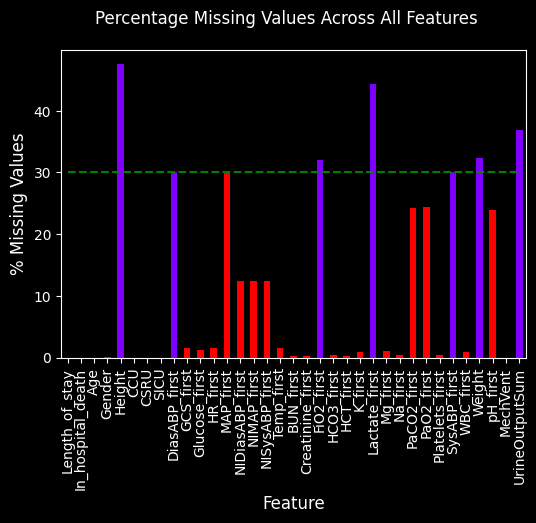

In [4]:
## Plot percentage of missing values (NaNs) for each feature
cutoff = 30 # we will remove features missing in more than 20% of the samples
fig = plt.figure(figsize=(6, 4))
percent_missing = (dfICU.isna().sum() / dfICU.shape[0]) * 100
percent_missing.plot(kind = 'bar', color = cm.rainbow(np.linspace(0, 1, 2))[(percent_missing <= cutoff).values.astype(int)])
plt.plot(np.arange(dfICU.shape[1]), np.repeat(cutoff, dfICU.shape[1]), 'g--')
fig.suptitle('Percentage Missing Values Across All Features', fontsize = 12)
plt.xlabel('Feature', fontsize = 12)
plt.ylabel('% Missing Values', fontsize = 12);

In [5]:
## Wrangle the dataframe
# Retain features with <= cutoff percentage missing values
dfICU = dfICU.loc[:, dfICU.columns[percent_missing <= cutoff]]

# Collate different one-hot-encoded ICU-type columns into a single column called ICU
dfICU.loc[dfICU['CCU'] == 1, 'ICU'] = 1
dfICU.loc[dfICU['CSRU'] == 1, 'ICU'] = 2
dfICU.loc[dfICU['SICU'] == 1, 'ICU'] = 3
dfICU.loc[(dfICU['CCU'] == 0 ) & (dfICU['CSRU'] == 0) & (dfICU['SICU'] == 0), 'ICU'] = 4
dfICU.drop(['CCU', 'CSRU', 'SICU'], axis = 1, inplace = True)

In [6]:
# Create lists of ordinal, categorical, and continuous features
ordinal_features = ['GCS_first']
categorical_features = [ 'Gender', 'ICU', 'MechVent']
continuous_features = dfICU.columns[~dfICU.columns.isin(ordinal_features + categorical_features)].to_list()
dfICU.head(5)

,Length_of_stay,In_hospital_death,Age,Gender,GCS_first,Glucose_first,HR_first,MAP_first,NIDiasABP_first,NIMAP_first,NISysABP_first,Temp_first,BUN_first,Creatinine_first,HCO3_first,HCT_first,K_first,Mg_first,Na_first,PaCO2_first,PaO2_first,Platelets_first,WBC_first,pH_first,MechVent,ICU
recordid,,,,,,,,,,,,,,,,,,,,,,,,,,
132539,5,0,54,0.0,15.0,205.0,73.0,NaN,65.0,92.33,147.0,35.1,13.0,0.8,26.0,33.7,4.4,1.5,137.0,NaN,NaN,221.0,11.2,NaN,0,3.0
132540,8,0,76,1.0,3.0,105.0,88.0,79.0,38.0,49.33,72.0,35.2,16.0,0.8,21.0,24.7,4.3,3.1,139.0,34.0,344.0,164.0,7.4,7.45,1,2.0
132541,19,0,44,0.0,7.0,141.0,100.0,107.0,84.0,100.30,133.0,37.8,8.0,0.4,24.0,28.5,3.3,1.9,137.0,37.0,65.0,72.0,4.2,7.51,1,4.0
132543,9,0,68,1.0,15.0,129.0,79.0,NaN,63.0,86.67,134.0,36.3,23.0,0.9,28.0,41.3,4.0,2.1,140.0,NaN,NaN,391.0,11.5,NaN,0,4.0
132545,4,0,88,0.0,15.0,113.0,93.0,NaN,41.0,75.33,144.0,37.8,45.0,1.0,18.0,22.6,6.0,1.5,140.0,NaN,NaN,109.0,3.8,NaN,0,4.0


In [7]:
# Assume df is your DataFrame and 'survived' and 'length_of_stay' are your target columns
X = dfICU.drop(['In_hospital_death', 'Length_of_stay'], axis=1)
y = dfICU[['In_hospital_death', 'Length_of_stay']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
num_labels_death = len(np.unique(y_train['In_hospital_death']))
num_labels_stay = len(np.unique(y_train['Length_of_stay']))
num_features = X_train.shape[1]
num_samples = X_train.shape[0]
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))
print('Number of output labels = %d, %d'%(num_labels_death, num_labels_stay))

Number of training samples = 6308
Number of features = 24
Number of output labels = 2, 98


In [9]:
X_train.shape

(6308, 24)

In [10]:
y_train.shape

(6308, 2)

In [12]:
X_test.shape

(1578, 24)

In [13]:
# Y_train.shape[0]
y_test.shape

(1578, 2)

In [ ]:
## Custom ordinal encoder
class CustomOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, ordinal_cols_dict: dict):
        self.ordinal_cols_dict = ordinal_cols_dict

    def fit(self, X: pd.DataFrame, y = None):
        return self

    def transform(self, X: pd.DataFrame, y = None):
        for col, order in self.ordinal_cols_dict.items():
            cat_type = CategoricalDtype(categories = self.ordinal_cols_dict[col], ordered = True)
            X[col] = X[col].astype(cat_type).factorize(sort = True)[0]
            X[col] = X[col].astype(CategoricalDtype(ordered = True))
            X[col] = X[col].replace(-1, np.nan)
        return X

    def fit_transform(self, X: pd.DataFrame, y = None):
        self.fit(X)
        return self.transform(X)

In [ ]:
## Custom categorical encoder
class CustomCategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols: list):
        self.categorical_cols = categorical_cols

    def fit(self, X: pd.DataFrame, y = None):
        return self

    def transform(self, X: pd.DataFrame, y = None):
        for col in self.categorical_cols:
            cat_type = 'category'
            X[col] = X[col].astype(cat_type).factorize()[0]
            X[col] = X[col].astype('category')
            X[col] = X[col].replace(-1, np.nan)
        return X

    def fit_transform(self, X: pd.DataFrame, y = None):
        self.fit(X)
        return self.transform(X)

In [14]:
ordinal_transformer = Pipeline(steps = [('ordinalenc', OrdinalEncoder()), ('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'constant'))])

categorical_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'median'))])

continuous_transformer = Pipeline(steps = [('scaler', StandardScaler()), ('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'mean'))])

preprocessor = ColumnTransformer(transformers = [('ord', ordinal_transformer, ordinal_features),
                                                 ('cat', categorical_transformer, categorical_features),
                                                 ('num', continuous_transformer, continuous_features)
                                                 ])

model_pipeline = Pipeline(steps = [('preprocessor', preprocessor)])

In [25]:
from keras.layers import Input, Dense
from keras.models import Model
# Define the model
input_layer = Input(shape=(X_train.shape[1],))
dense1 = Dense(10, activation='relu')(input_layer)
dense2 = Dense(1, activation='sigmoid', name='survived')(dense1)

# Define the input layer
input_layer = Input(shape=(X_train.shape[1],))

# Define the shared layers
dense1 = Dense(10, activation='relu')(input_layer)

# Define the output layer for In_hospital_death
output_death = Dense(1, activation='sigmoid', name='survived')(dense1)

# Define the output layer for Length_of_stay
output_stay = Dense(1, name='length_of_stay_output')(dense1)

# Define the model
model = Model(inputs=input_layer, outputs=[output_death, output_stay])


In [26]:
output_death = model.predict(X_test)
output_stay = model.predict(X_test)


50/50 [==============================] - 0s 2ms/step


In [27]:
# model = Model(inputs=input_layer, outputs=[output_layer_1, output_layer_2])

# Define the model
input_layer = Input(shape=(X_train.shape[1],))
dense1 = Dense(10, activation='relu')(input_layer)
output_death = Dense(1, activation='sigmoid', name='survived')(dense1)
output_stay = Dense(1, name='length_of_stay_output')(dense1)

# Compile the model
model = Model(inputs=input_layer, outputs=[output_death, output_stay])
model.compile(optimizer=Adam(), 
              loss={'survived': 'binary_crossentropy', 'length_of_stay_output': 'mse'},
              metrics={'survived': 'accuracy'})

# Fit the model
model.fit(X_train, {'survived': y_train['In_hospital_death'], 'length_of_stay_output': y_train['Length_of_stay']}, epochs=10)

# Evaluate the model
model.evaluate(X_test, {'survived': y_test['In_hospital_death'], 'length_of_stay_output': y_test['Length_of_stay']})

Epoch 1/10
198/198 [==============================] - 1s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8562
Epoch 2/10
198/198 [==============================] - 0s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8584
Epoch 3/10
198/198 [==============================] - 0s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8584
Epoch 4/10
198/198 [==============================] - 0s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8584
Epoch 5/10
198/198 [==============================] - 0s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8584
Epoch 6/10
198/198 [==============================] - 0s 2ms/step - loss: nan - survived_loss: nan - length_of_stay_output_loss: nan - survived_accuracy: 0.8584
Epoch 7/10
198/198 [==============

[nan, nan, nan, 0.85487961769104]